# Forest management for important tree species

## Foreword
Selecting tree species for sustainable forest management is a multidimensional process that balances biological potential with economic utility. The Importance Value Index (IVI) serves as the primary ecological compass in this selection, as it identifies which species are currently defining the forest's structure through their relative frequency, density, and dominance; high-IVI species are typically the most reliable for long-term management because they have already proven their adaptability to the local site conditions. However, a high IVI must be cross-referenced with botanical and ecological traits, such as successional guild (pioneer vs. climax) and reproductive strategy, to ensure that harvesting does not disrupt the forest's regenerative capacity or unique biodiversity.

From a silvicultural and wood properties perspective, the selection transitions from "what is there" to "what is useful." Silvicultural analysis assesses a species' growth rate and response to thinning, while an evaluation of wood properties—such as density, durability, and grain—determines its end-use suitability, whether for high-value furniture, heavy construction, or biomass. Ultimately, the ideal species for selection are those that maintain a high ecological "standing" (high IVI) while possessing wood properties that meet market demands, ensuring that the forest remains both biologically resilient and economically viable for future generations.

According to the [IVI Notebook](https://github.com/miguelif92/IVI-ForstEcol/blob/main/notebook/1_ivi.ipynb), we select tree species like Sande (*Brosimum utile*) and Cativo (*Prioria copaifera*) for an structural analysis that provide a guide for forest management decisions. Besides, a [technical and summarised sheet](https://github.com/miguelif92/IVI-ForstEcol/blob/main/doc/tree_species.pdf) was designed aiming to provide to users information about tree species' properties. However, it is important to make a deep research about the species that could be selected for forest management by emphasizing in botanical, ecological, silvicultural, social, economical and cultural aspects.

The methodology workflow goes according to what is shown in [diameter distribution notebook](https://github.com/miguelif92/IVI-ForstEcol/blob/main/notebook/2_diameter_distribution.ipynb) aiming to compare dendrometrical properties for these tree species.


## 1. Import libraries

In [16]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import openpyxl
import seaborn as sns
from inventory_data import load_inventory

## 2. Data import

In [17]:
df = load_inventory()

## 3. Diameter distribution status

In [18]:
# Select all rows with Scientific name == 'Prioria copaifera' or 'Brosimum utile'
species_df = df[df['Scientific name'].isin(['Prioria copaifera', 'Brosimum utile'])].copy()

print(f"Total prior species' trees: {len(species_df)}")
species_df.info()

Total prior species' trees: 896
<class 'pandas.core.frame.DataFrame'>
Index: 896 entries, 11 to 11984
Data columns (total 15 columns):
 #   Column                 Non-Null Count  Dtype   
---  ------                 --------------  -----   
 0   Line Number            896 non-null    category
 1   Plot                   896 non-null    category
 2   Subplot                896 non-null    category
 3   Tree number            896 non-null    category
 4   Tree name              896 non-null    category
 5   Scientific name        896 non-null    category
 6   Commercial group       896 non-null    category
 7   DBH [cm]               896 non-null    float64 
 8   DBH [m]                896 non-null    float64 
 9   Commercial height [m]  896 non-null    float64 
 10  Stem quality           896 non-null    category
 11  Observations           29 non-null     object  
 12  Basal area [m2]        896 non-null    float64 
 13  Volume [m3]            896 non-null    float64 
 14  DBH Class   

In [19]:
#The of each line in hectares
plot_size = 5000
plot_size_ha = plot_size/10000

print(f'The area of sample plots is: {plot_size} m², which means {plot_size_ha} ha.')

# counts per line
plot_counts = df.groupby('Line Number')['Plot'].nunique().sort_index()
print(plot_counts)

line_area_df = plot_counts.rename('plot_count').to_frame().assign(line_area_ha=lambda x: x['plot_count'] * plot_size_ha)
print(line_area_df)

The area of sample plots is: 5000 m², which means 0.5 ha.
Line Number
1    12
2    19
3    18
4     7
5    10
6    12
7    11
Name: Plot, dtype: int64
             plot_count  line_area_ha
Line Number                          
1                    12           6.0
2                    19           9.5
3                    18           9.0
4                     7           3.5
5                    10           5.0
6                    12           6.0
7                    11           5.5


C:\Users\migue\AppData\Local\Temp\ipykernel_20976\3259818346.py:8: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  plot_counts = df.groupby('Line Number')['Plot'].nunique().sort_index()


### 3.1 Diameter distribution

C:\Users\migue\AppData\Local\Temp\ipykernel_20976\469607468.py:23: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  counts = line_data.groupby(["DBH Class", "Scientific name"]).size().unstack(fill_value=0)
C:\Users\migue\AppData\Local\Temp\ipykernel_20976\469607468.py:23: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  counts = line_data.groupby(["DBH Class", "Scientific name"]).size().unstack(fill_value=0)
C:\Users\migue\AppData\Local\Temp\ipykernel_20976\469607468.py:23: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to re

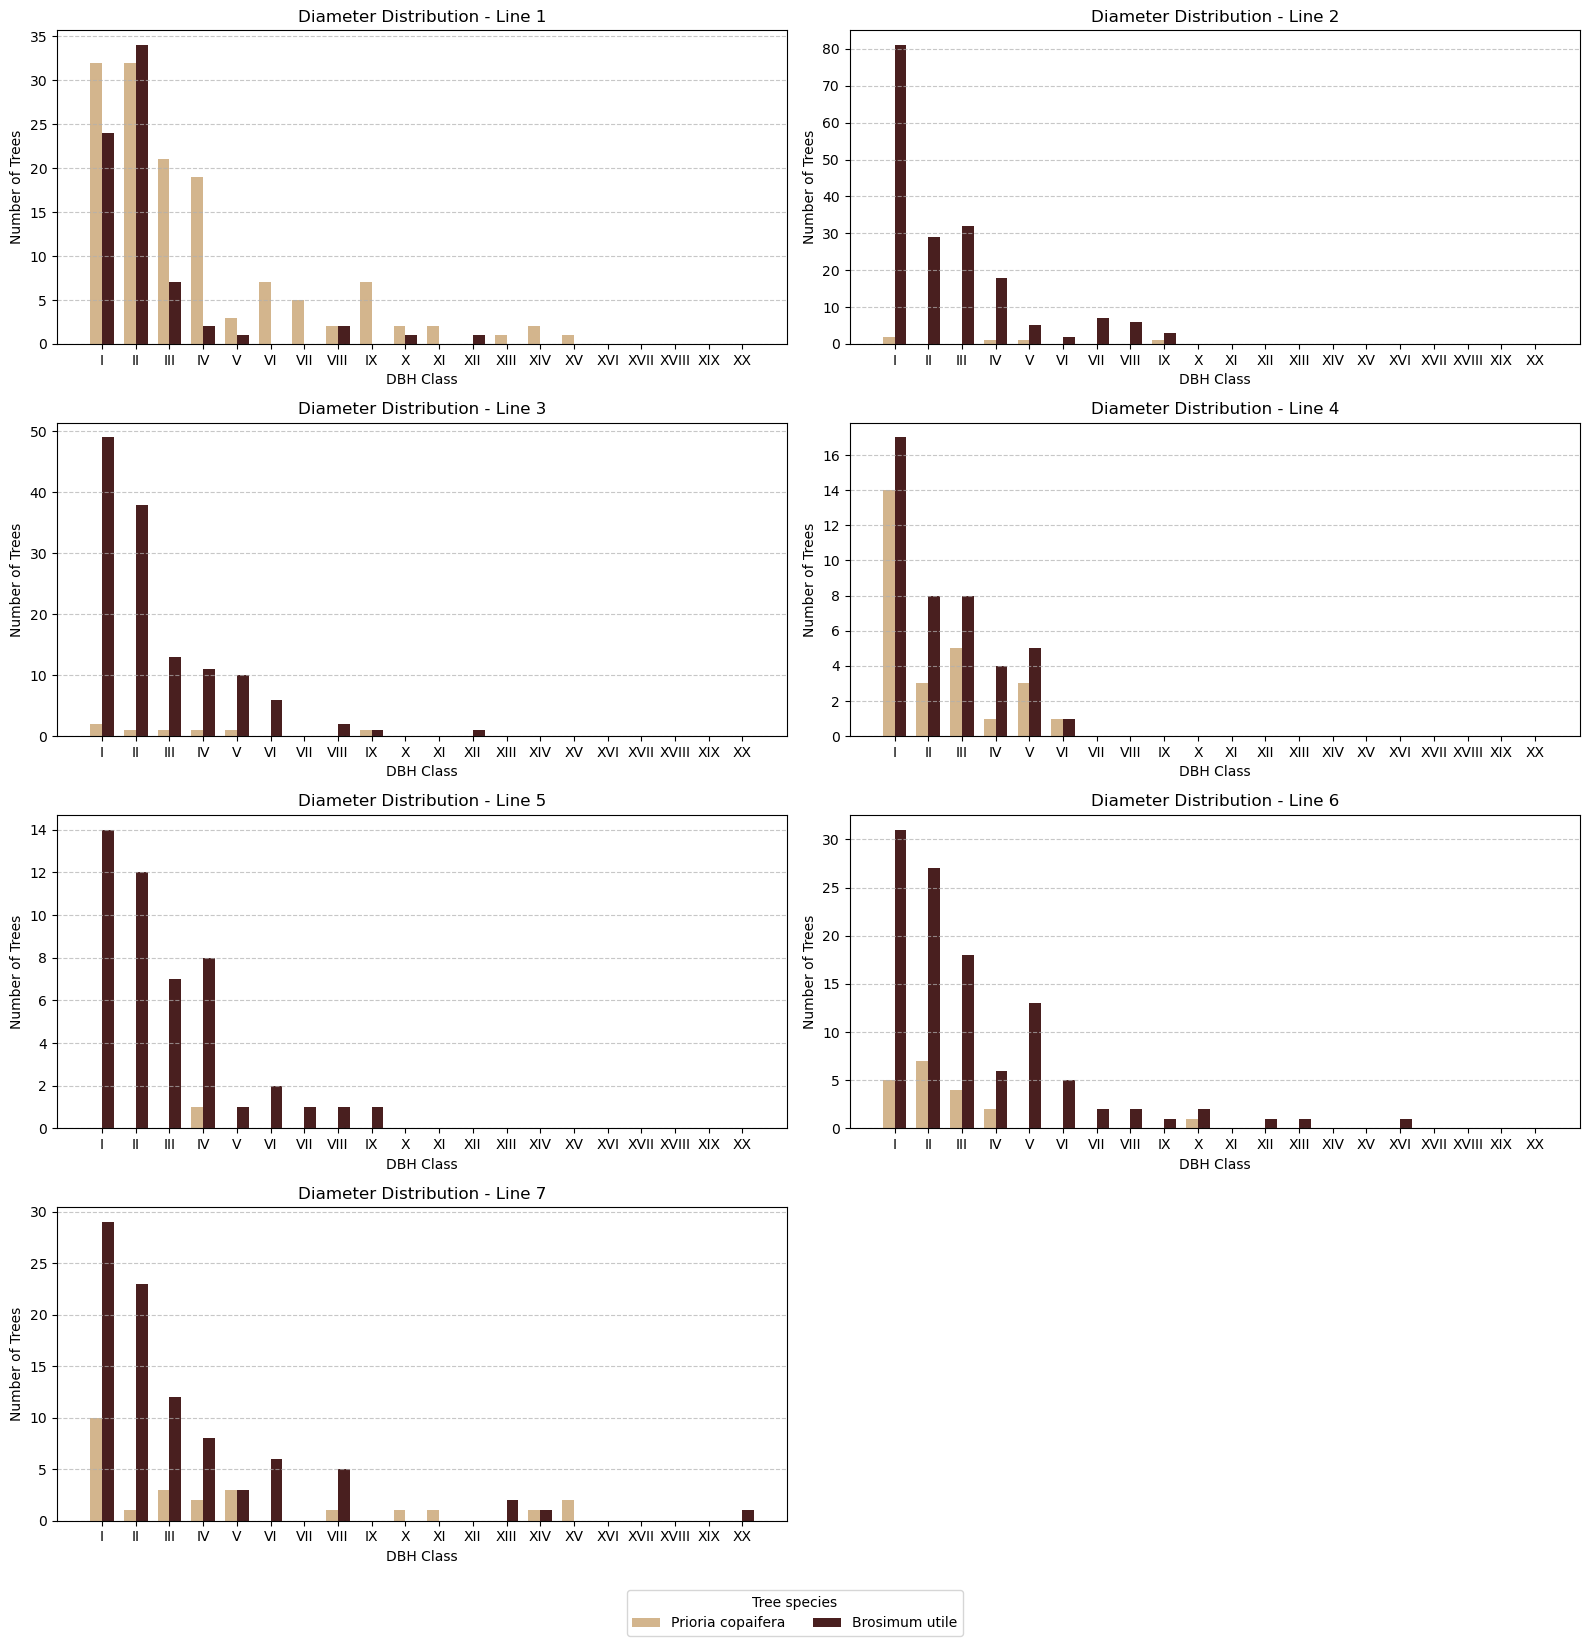

In [20]:
# Define color mapping and species order
species_order = ['Prioria copaifera', 'Brosimum utile']
color_map = {
    'Brosimum utile': "#491f1f",
    'Prioria copaifera': "#D3B58D"
}

# Create a 4x2 matrix of subplots, one for each line number, with side-by-side bars per species
fig, axes = plt.subplots(4, 2, figsize=(16, 16))
axes = axes.flatten()

# determine ordered DBH Class categories
if hasattr(species_df["DBH Class"], "cat"):
    dbh_categories = list(species_df["DBH Class"].cat.categories)
else:
    dbh_categories = sorted(species_df["DBH Class"].unique())

width = 0.35

for i, line_num in enumerate(range(1, 8)):
    line_data = species_df.loc[species_df["Line Number"] == line_num]
    # counts per DBH Class and Scientific name
    counts = line_data.groupby(["DBH Class", "Scientific name"]).size().unstack(fill_value=0)

    # ensure both species are present in the columns and in the specified order
    for s in species_order:
        if s not in counts.columns:
            counts[s] = 0
    counts = counts[species_order]

    # ensure all DBH categories are present
    counts = counts.reindex(index=dbh_categories, fill_value=0)

    x = np.arange(len(counts))

    for j, species in enumerate(species_order):
        offsets = (j - (len(species_order) - 1)/2) * width
        axes[i].bar(x + offsets, counts[species].values, width, label=species if i == 0 else "", color=color_map.get(species))

    axes[i].set_xlabel('DBH Class')
    axes[i].set_ylabel('Number of Trees')
    axes[i].set_title(f'Diameter Distribution - Line {line_num}')
    axes[i].set_xticks(x)
    axes[i].grid(axis='y', linestyle='--', alpha=0.7)
    axes[i].set_xticklabels(counts.index, rotation=0)

# Place a single horizontal legend centered below all subplots with a title
legend = fig.legend(ncol=len(species_order), loc='lower center', bbox_to_anchor=(0.5, -0.03), frameon=True, title='Tree species')
legend.get_title().set_fontsize('medium')
try:
    legend._legend_box.align = "center"
except Exception:
    pass

# Hide the last empty subplot
axes[7].set_visible(False)

# Adjust layout to make room for the legend (reduced bottom space)
plt.tight_layout(rect=[0, 0.01, 1, 1])
plt.show()

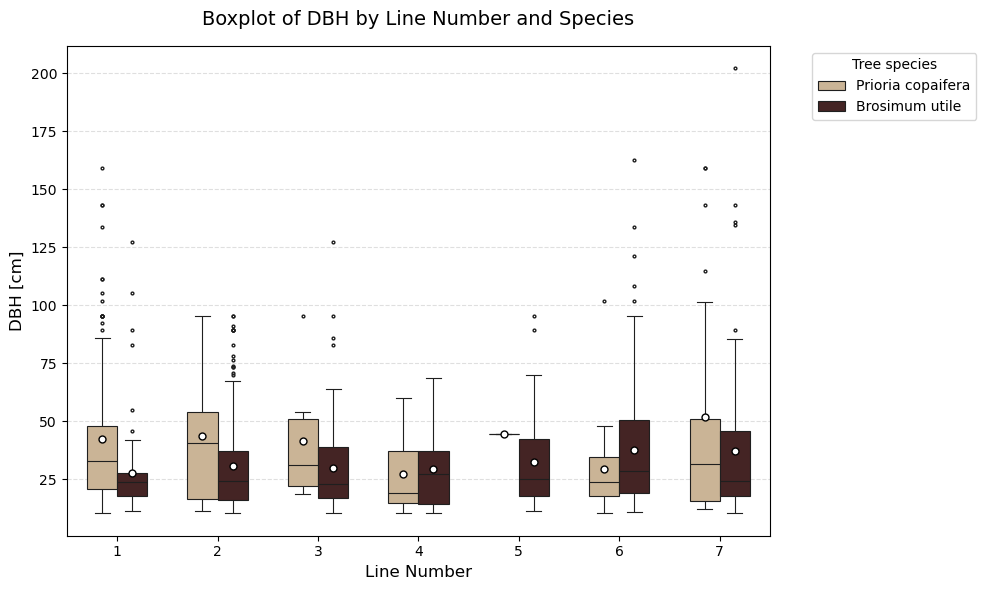

In [21]:
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Filter the data to include ONLY the two target species
# This ensures the legend doesn't pick up extra species
filtered_plot_df = species_df[species_df['Scientific name'].isin(species_order)].copy()

# 2. Convert Line Number to integer for clean X-axis labels (no .0)
filtered_plot_df['Line Number'] = filtered_plot_df['Line Number'].astype(int)

# Define mapping and order
species_order = ['Prioria copaifera', 'Brosimum utile']
color_map = {
    'Brosimum utile': "#491f1f",
    'Prioria copaifera': "#D3B58D"
}

plt.figure(figsize=(10, 6))

# 3. Create the plot using the filtered data
sns.boxplot(
    x="Line Number",
    y="DBH [cm]",
    hue="Scientific name",
    hue_order=species_order, # Explicitly set legend order
    data = species_df,
    palette=[color_map[s] for s in species_order],
    width=0.6,
    linewidth=0.8,
    showmeans=True,
    meanprops={"marker":"o", "markerfacecolor":"white", "markeredgecolor":"black", "markersize":"5"},
    fliersize=2
)

plt.title("Boxplot of DBH by Line Number and Species", fontsize=14, pad=15)
plt.xlabel("Line Number", fontsize=12)
plt.ylabel("DBH [cm]", fontsize=12)
plt.grid(axis='y', linestyle='--', alpha=0.4)

# Optional: Place legend outside if it overlaps data
plt.legend(title="Tree species", bbox_to_anchor=(1.05, 1), loc='upper left')

plt.tight_layout()
plt.show()

C:\Users\migue\AppData\Local\Temp\ipykernel_20976\1820953014.py:19: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  plot_counts = df.groupby('Line Number')['Plot'].nunique()
C:\Users\migue\AppData\Local\Temp\ipykernel_20976\1820953014.py:34: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  counts = line_data.groupby(["DBH Class", "Scientific name"]).size().unstack(fill_value=0)
C:\Users\migue\AppData\Local\Temp\ipykernel_20976\1820953014.py:34: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or obse

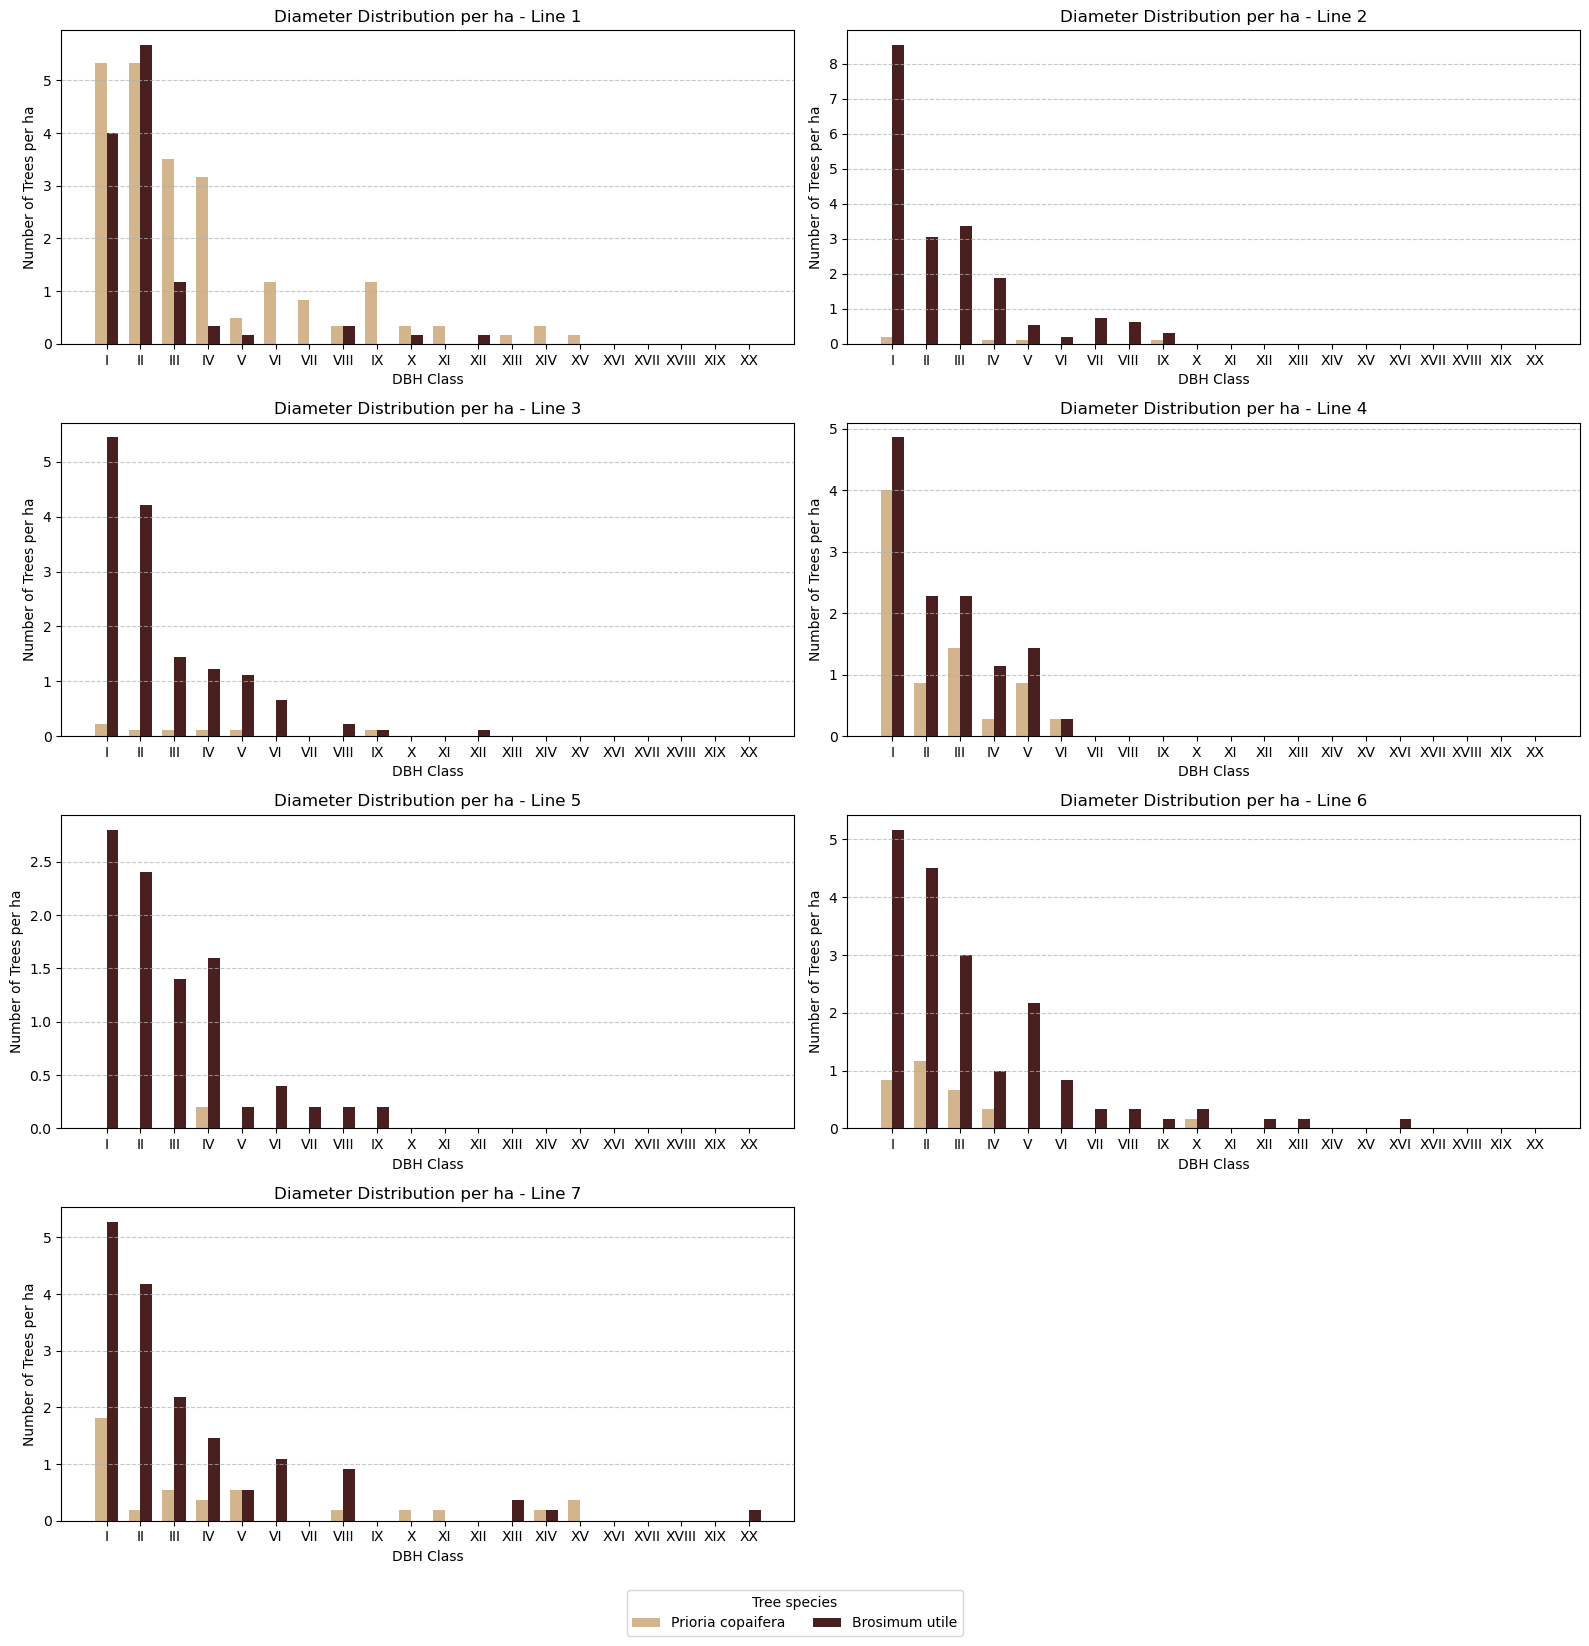

In [22]:
# Create a 4x2 matrix of subplots, one for each line number
# Side-by-side bars per species showing counts per hectare
species_order = ['Prioria copaifera', 'Brosimum utile']
color_map = {
    'Brosimum utile': "#491f1f",
    'Prioria copaifera': "#D3B58D"
}

fig, axes = plt.subplots(4, 2, figsize=(16, 16))
axes = axes.flatten()

# Ensure plot area and counts exist; fall back to defaults if not
try:
    plot_size_ha
except NameError:
    plot_size = 5000
    plot_size_ha = plot_size / 10000

plot_counts = df.groupby('Line Number')['Plot'].nunique()
line_area_ha = plot_counts * plot_size_ha

# determine ordered DBH Class categories
if hasattr(species_df["DBH Class"], "cat"):
    dbh_categories = list(species_df["DBH Class"].cat.categories)
else:
    dbh_categories = sorted(species_df["DBH Class"].unique())

width = 0.35

for i, line_num in enumerate(range(1, 8)):
    line_data = species_df[species_df["Line Number"] == line_num]

    # counts per DBH Class and Scientific name
    counts = line_data.groupby(["DBH Class", "Scientific name"]).size().unstack(fill_value=0)

    # ensure both species are present and in order
    for s in species_order:
        if s not in counts.columns:
            counts[s] = 0
    counts = counts[species_order]

    # ensure all DBH categories are present
    counts = counts.reindex(index=dbh_categories, fill_value=0)

    # compute per-hectare values
    area = line_area_ha.get(line_num, np.nan)
    if area and area > 0:
        counts_per_ha = counts / area
    else:
        counts_per_ha = counts.copy() * np.nan

    x = np.arange(len(counts_per_ha))

    for j, species in enumerate(species_order):
        offsets = (j - (len(species_order) - 1)/2) * width
        axes[i].bar(x + offsets, counts_per_ha[species].values, width, label=species if i == 0 else "", color=color_map.get(species))

    axes[i].set_xlabel('DBH Class')
    axes[i].set_ylabel('Number of Trees per ha')
    axes[i].set_title(f'Diameter Distribution per ha - Line {line_num}')
    axes[i].set_xticks(x)
    axes[i].grid(axis='y', linestyle='--', alpha=0.7)
    axes[i].set_xticklabels(counts_per_ha.index, rotation=0)

# Place a single horizontal legend centered below all subplots with a title
legend = fig.legend(ncol=len(species_order), loc='lower center', bbox_to_anchor=(0.5, -0.03), frameon=True, title='Tree species')
legend.get_title().set_fontsize('medium')
try:
    legend._legend_box.align = "center"
except Exception:
    pass

# Hide the last empty subplot
axes[7].set_visible(False)

# Adjust layout to make room for the legend
plt.tight_layout(rect=[0, 0.01, 1, 1])
plt.show()

### 3.2 Basal area

C:\Users\migue\AppData\Local\Temp\ipykernel_20976\3860364114.py:24: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  .groupby(["DBH Class", "Scientific name"])["Basal area [m2]"].sum()
C:\Users\migue\AppData\Local\Temp\ipykernel_20976\3860364114.py:24: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  .groupby(["DBH Class", "Scientific name"])["Basal area [m2]"].sum()
C:\Users\migue\AppData\Local\Temp\ipykernel_20976\3860364114.py:24: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to

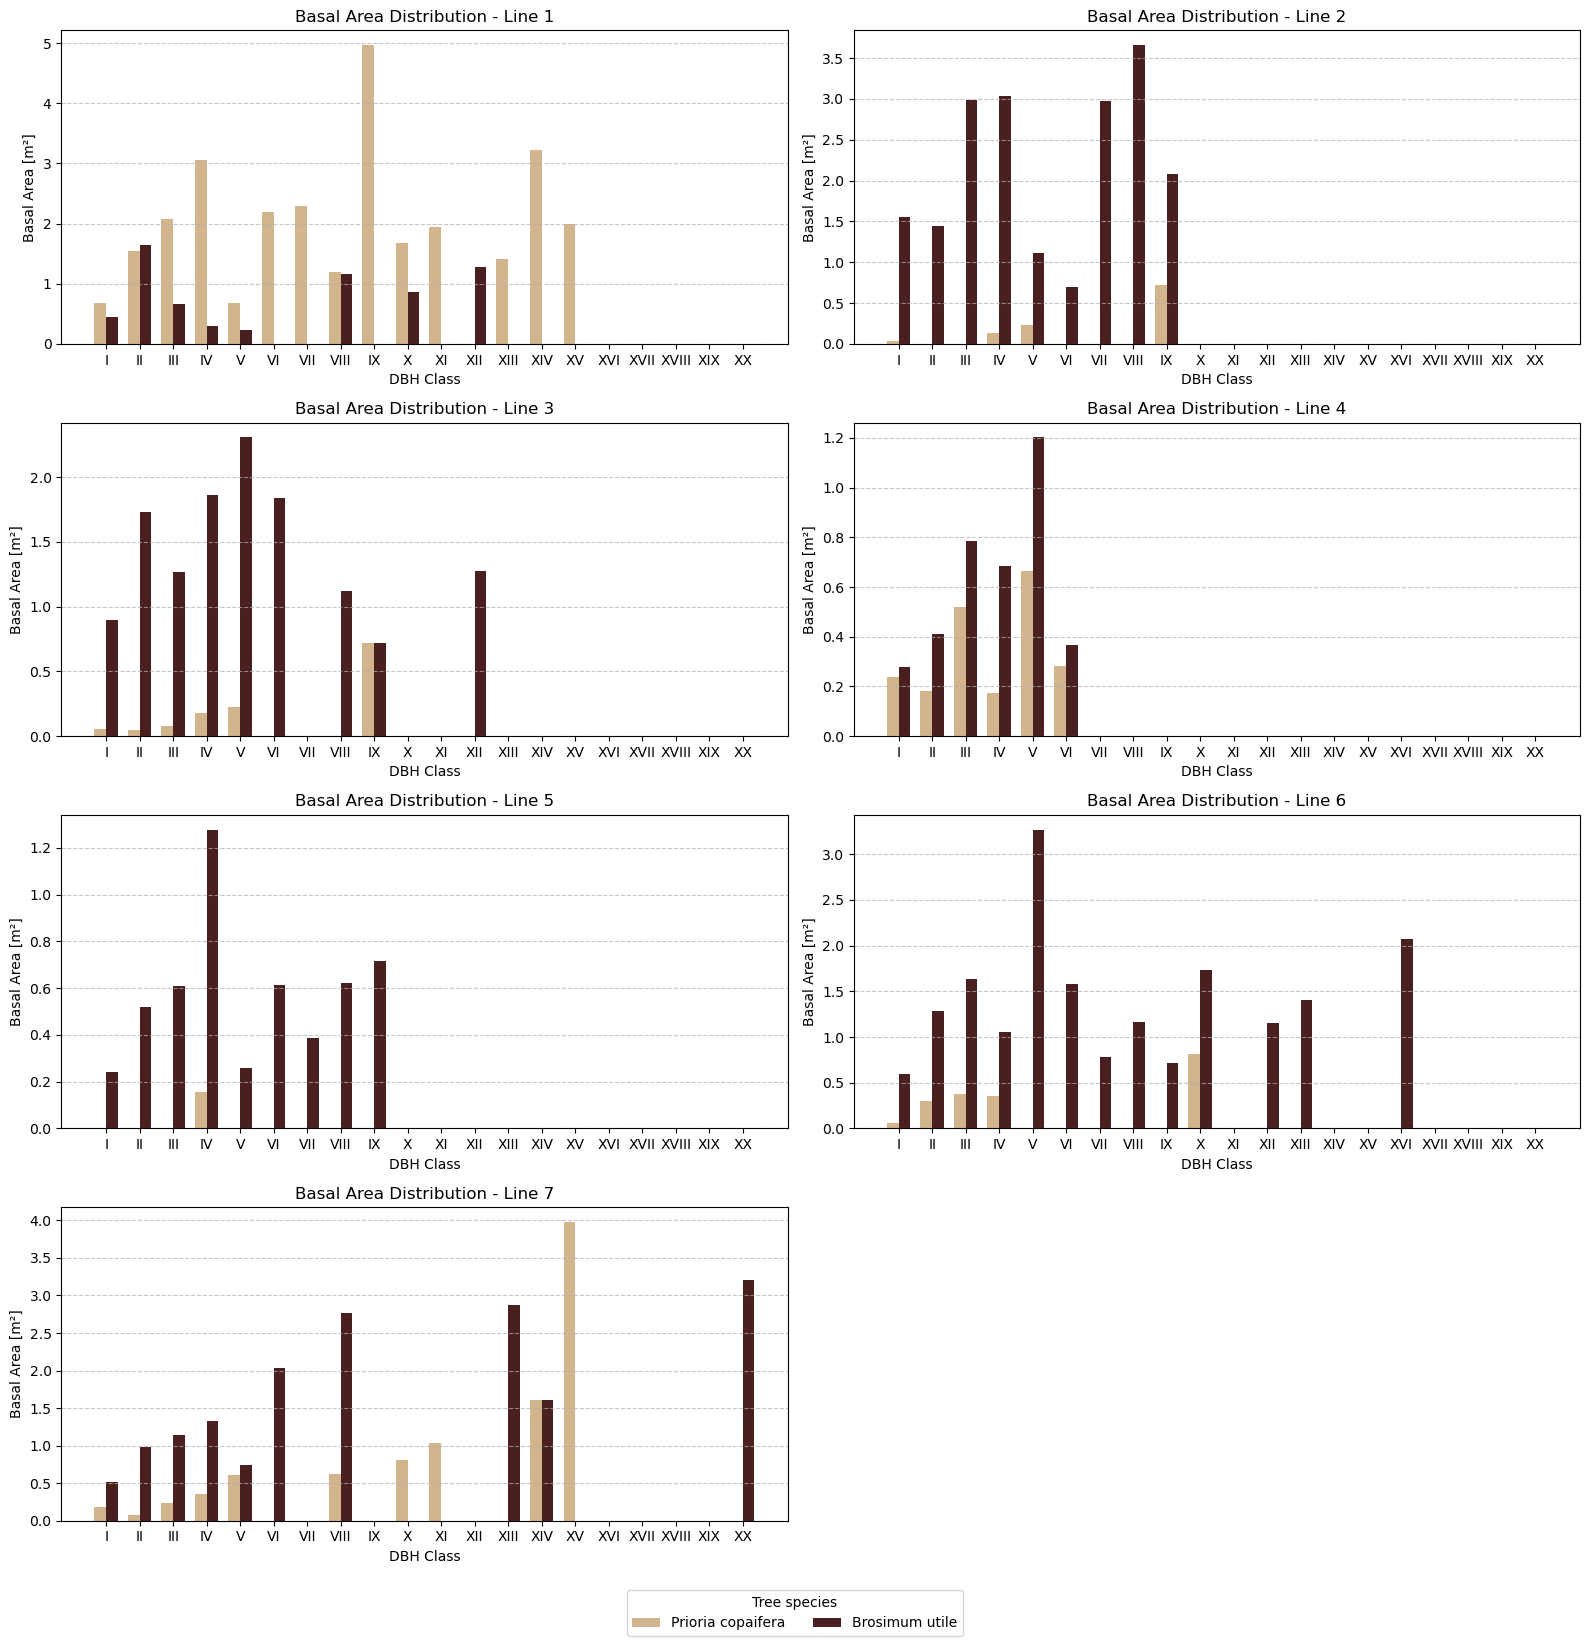

In [23]:
# Side-by-side Basal Area by DBH Class for Prioria copaifera and Brosimum utile
species_order = ['Prioria copaifera', 'Brosimum utile']
color_map = {
    'Brosimum utile': "#491f1f",
    'Prioria copaifera': "#D3B58D"
}

fig, axes = plt.subplots(4, 2, figsize=(16, 16))
axes = axes.flatten()

# determine ordered DBH Class categories
if hasattr(species_df["DBH Class"], "cat"):
    dbh_categories = list(species_df["DBH Class"].cat.categories)
else:
    dbh_categories = sorted(species_df["DBH Class"].unique())

width = 0.35

for i, line_num in enumerate(range(1, 8)):
    line_data = species_df.loc[species_df["Line Number"] == line_num]
    # Basal area summed by DBH Class and Scientific name
    ba = (
        line_data
        .groupby(["DBH Class", "Scientific name"])["Basal area [m2]"].sum()
        .unstack(fill_value=0)
    )

    # ensure both species are present in the columns and in the specified order
    for s in species_order:
        if s not in ba.columns:
            ba[s] = 0
    ba = ba[species_order]

    # ensure all DBH categories are present
    ba = ba.reindex(index=dbh_categories, fill_value=0)

    x = np.arange(len(ba))

    for j, species in enumerate(species_order):
        offsets = (j - (len(species_order) - 1)/2) * width
        axes[i].bar(x + offsets, ba[species].values, width, label=species if i == 0 else "", color=color_map.get(species))

    axes[i].set_xlabel('DBH Class')
    axes[i].set_ylabel('Basal Area [m²]')
    axes[i].set_title(f'Basal Area Distribution - Line {line_num}')
    axes[i].set_xticks(x)
    axes[i].grid(axis='y', linestyle='--', alpha=0.7)
    axes[i].set_xticklabels(ba.index, rotation=0)

# Place a single horizontal legend centered below all subplots with a title
legend = fig.legend(ncol=len(species_order), loc='lower center', bbox_to_anchor=(0.5, -0.03), frameon=True, title='Tree species')
legend.get_title().set_fontsize('medium')
try:
    legend._legend_box.align = "center"
except Exception:
    pass

# Hide the last empty subplot
axes[7].set_visible(False)

# Adjust layout to make room for the legend (reduced bottom space)
plt.tight_layout(rect=[0, 0.01, 1, 1])
plt.show()


C:\Users\migue\AppData\Local\Temp\ipykernel_20976\1763254107.py:19: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  plot_counts = df.groupby('Line Number')['Plot'].nunique()
C:\Users\migue\AppData\Local\Temp\ipykernel_20976\1763254107.py:36: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  .groupby(["DBH Class", "Scientific name"])['Basal area [m2]']
C:\Users\migue\AppData\Local\Temp\ipykernel_20976\1763254107.py:36: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the futur

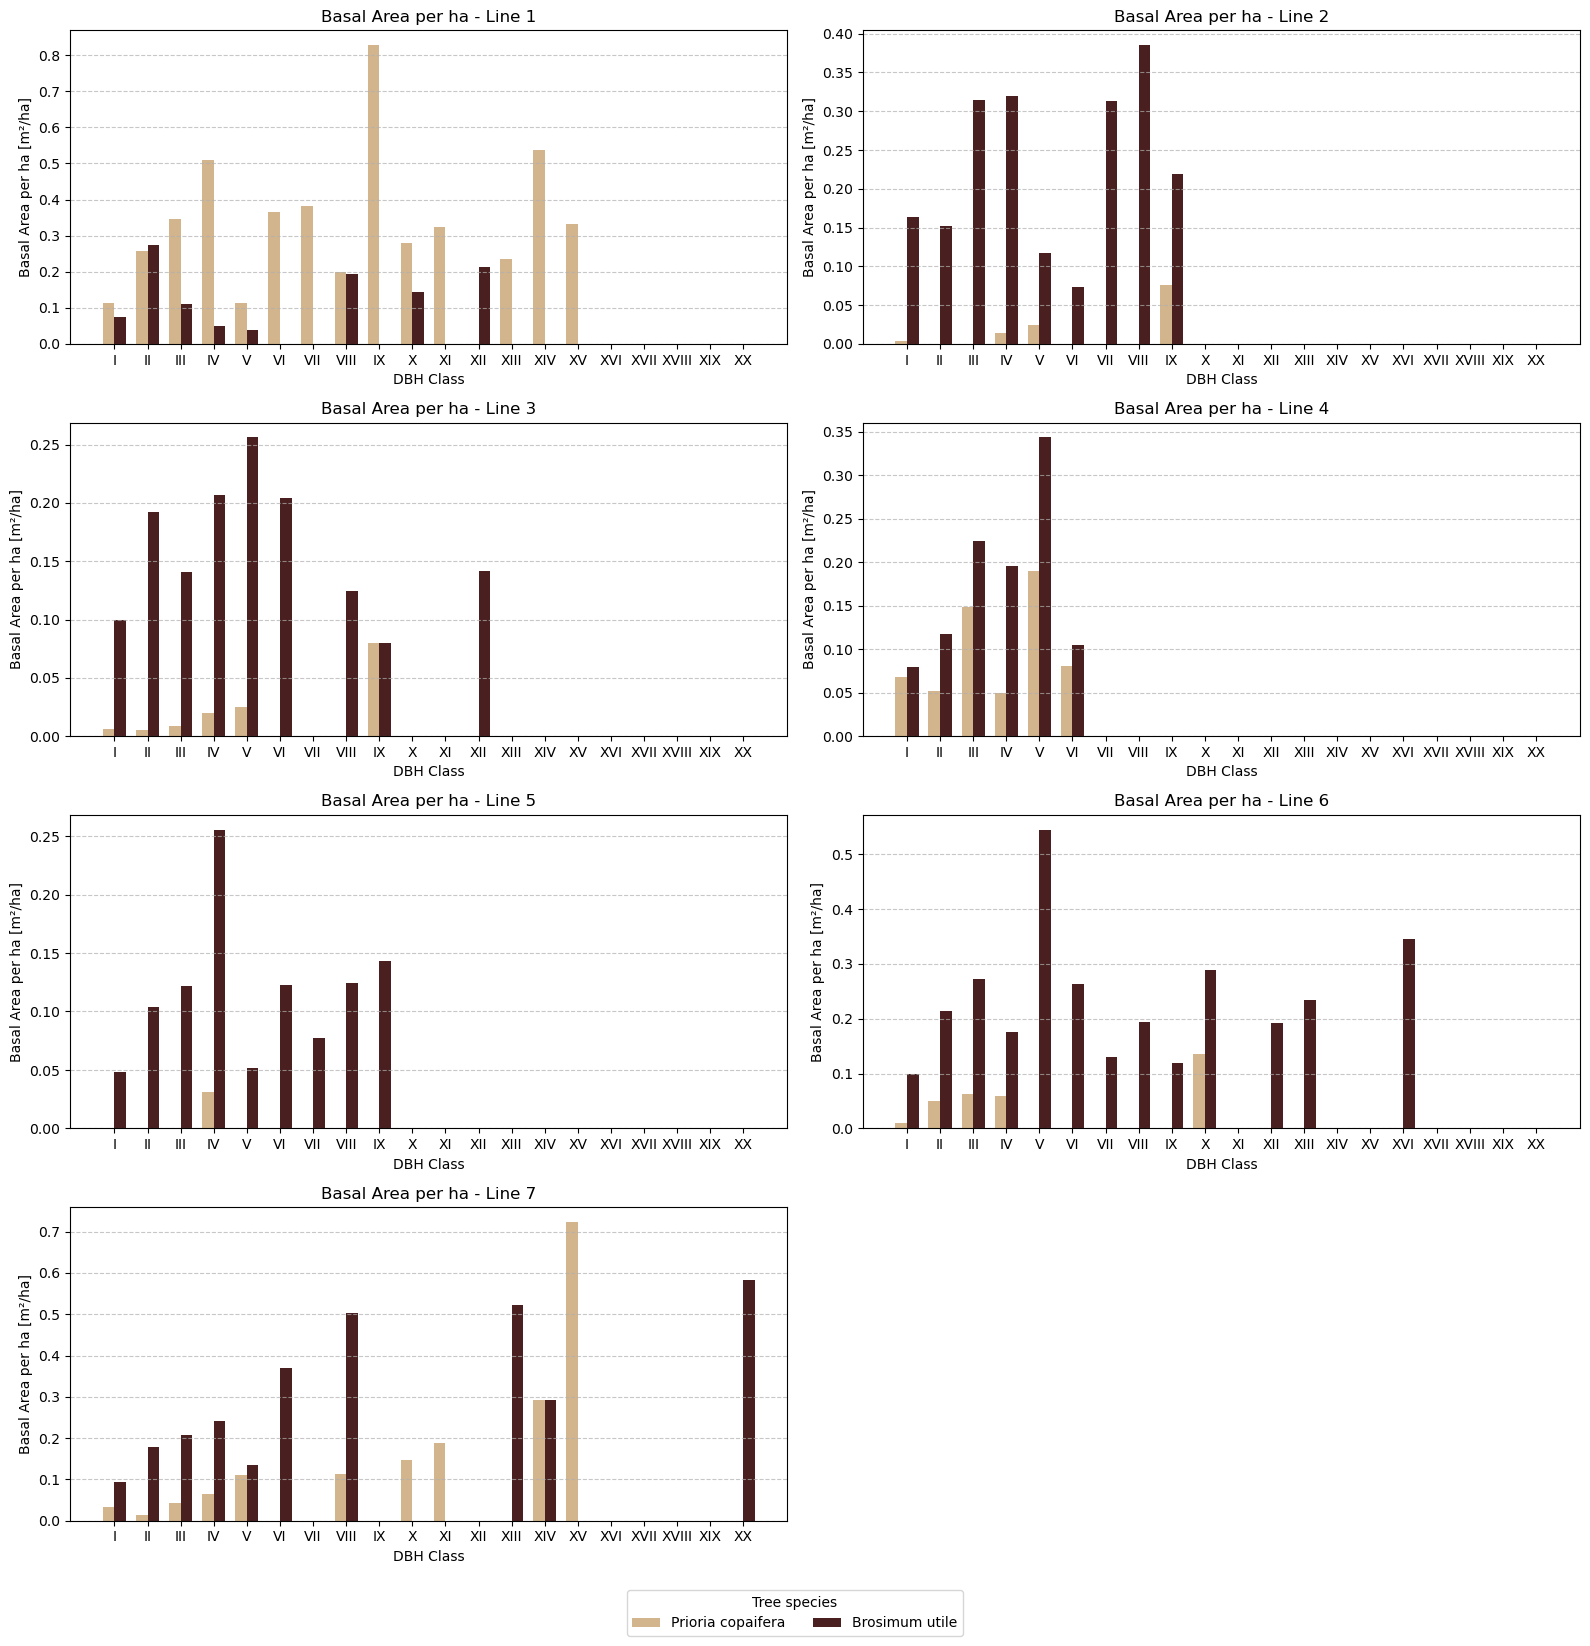

In [24]:
# Create a 4x2 matrix of subplots for Basal Area per ha by DBH Class for each line number
# Side-by-side bars per species
species_order = ['Prioria copaifera', 'Brosimum utile']
color_map = {
    'Brosimum utile': '#491f1f',
    'Prioria copaifera': '#D3B58D'
}

fig, axes = plt.subplots(4, 2, figsize=(16, 16))
axes = axes.flatten()

# Ensure plot area and counts exist; fall back to defaults if not
try:
    plot_size_ha
except NameError:
    plot_size = 5000
    plot_size_ha = plot_size / 10000

plot_counts = df.groupby('Line Number')['Plot'].nunique()
line_area_ha = plot_counts * plot_size_ha

# determine ordered DBH Class categories
if hasattr(df["DBH Class"], "cat"):
    dbh_categories = list(df["DBH Class"].cat.categories)
else:
    dbh_categories = sorted(df["DBH Class"].unique())

width = 0.35

for i, line_num in enumerate(range(1, 8)):
    line_data = species_df[species_df["Line Number"] == line_num]

    # Basal area summed by DBH Class and Scientific name
    ba = (
        line_data
        .groupby(["DBH Class", "Scientific name"])['Basal area [m2]']
        .sum()
        .unstack(fill_value=0)
    )

    # ensure both species are present and in the specified order
    for s in species_order:
        if s not in ba.columns:
            ba[s] = 0
    ba = ba[species_order]

    # ensure all DBH categories are present
    ba = ba.reindex(index=dbh_categories, fill_value=0)

    # compute per-hectare basal area
    area = line_area_ha.get(line_num, np.nan)
    if area and area > 0:
        ba_per_ha = ba / area
    else:
        ba_per_ha = ba * np.nan

    x = np.arange(len(ba_per_ha))

    for j, species in enumerate(species_order):
        offsets = (j - (len(species_order) - 1)/2) * width
        axes[i].bar(x + offsets, ba_per_ha[species].values, width, label=species if i == 0 else "", color=color_map.get(species))

    axes[i].set_xlabel('DBH Class')
    axes[i].set_ylabel('Basal Area per ha [m²/ha]')
    axes[i].set_title(f'Basal Area per ha - Line {line_num}')
    axes[i].set_xticks(x)
    axes[i].grid(axis='y', linestyle='--', alpha=0.7)
    axes[i].set_xticklabels(ba_per_ha.index, rotation=0)

# Place a single horizontal legend centered below all subplots with a title
legend = fig.legend(ncol=len(species_order), loc='lower center', bbox_to_anchor=(0.5, -0.03), frameon=True, title='Tree species')
legend.get_title().set_fontsize('medium')
try:
    legend._legend_box.align = "center"
except Exception:
    pass

# Hide the last empty subplot
axes[7].set_visible(False)

# Adjust layout to make room for the legend
plt.tight_layout(rect=[0, 0.01, 1, 1])
plt.show()

### 3.2 Volume distribution

C:\Users\migue\AppData\Local\Temp\ipykernel_20976\2208235151.py:24: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  .groupby(["DBH Class", "Scientific name"])["Volume [m3]"].sum()
C:\Users\migue\AppData\Local\Temp\ipykernel_20976\2208235151.py:24: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  .groupby(["DBH Class", "Scientific name"])["Volume [m3]"].sum()
C:\Users\migue\AppData\Local\Temp\ipykernel_20976\2208235151.py:24: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt t

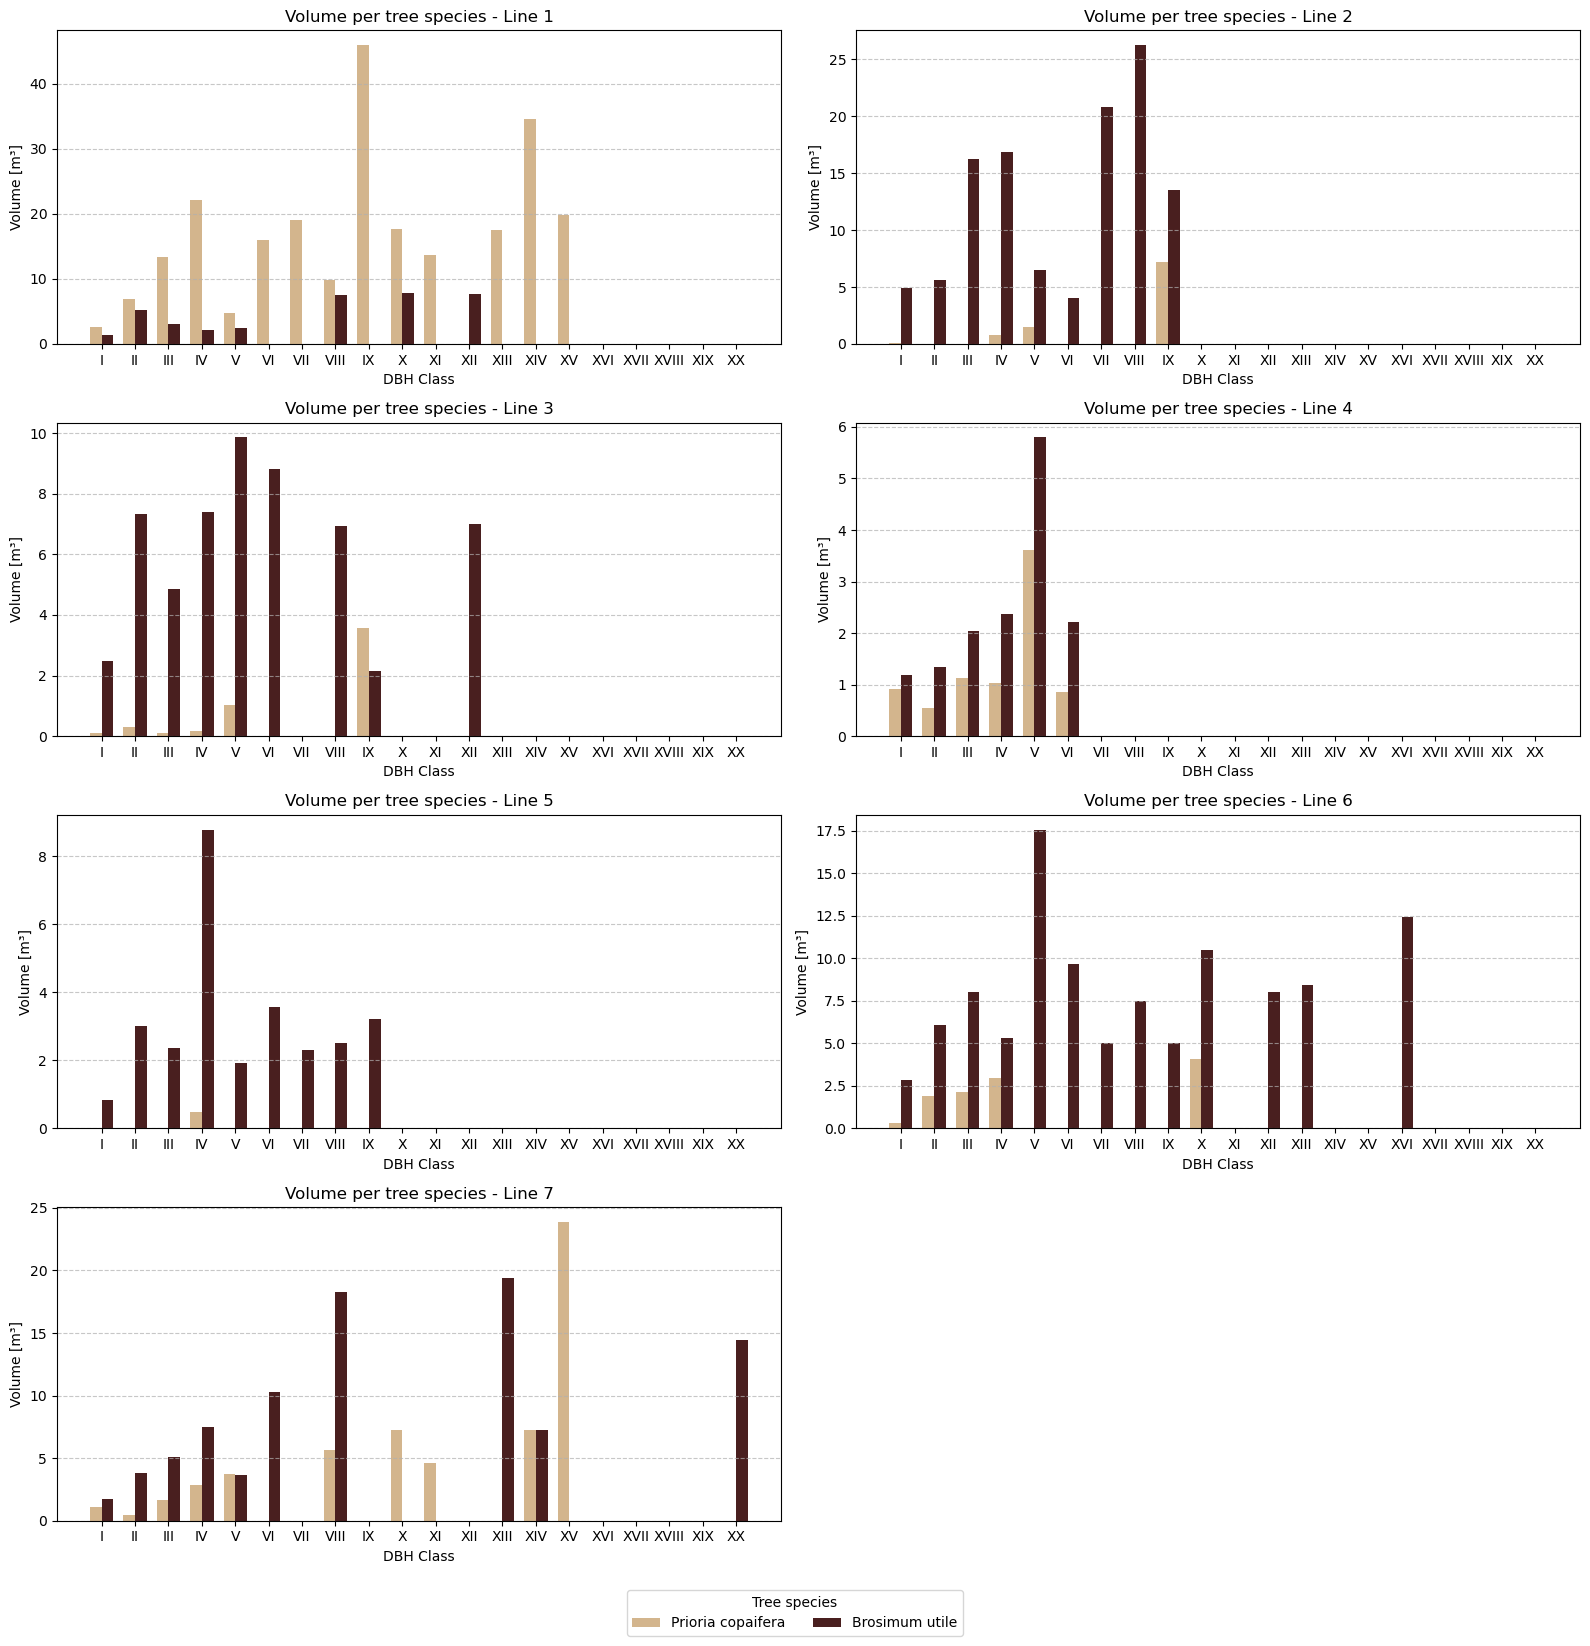

In [25]:
# Side-by-side Basal Area by DBH Class for Prioria copaifera and Brosimum utile
species_order = ['Prioria copaifera', 'Brosimum utile']
color_map = {
    'Brosimum utile': "#491f1f",
    'Prioria copaifera': "#D3B58D"
}

fig, axes = plt.subplots(4, 2, figsize=(16, 16))
axes = axes.flatten()

# determine ordered DBH Class categories
if hasattr(species_df["DBH Class"], "cat"):
    dbh_categories = list(species_df["DBH Class"].cat.categories)
else:
    dbh_categories = sorted(species_df["DBH Class"].unique())

width = 0.35

for i, line_num in enumerate(range(1, 8)):
    line_data = species_df.loc[species_df["Line Number"] == line_num]
    # Basal area summed by DBH Class and Scientific name
    ba = (
        line_data
        .groupby(["DBH Class", "Scientific name"])["Volume [m3]"].sum()
        .unstack(fill_value=0)
    )

    # ensure both species are present in the columns and in the specified order
    for s in species_order:
        if s not in ba.columns:
            ba[s] = 0
    ba = ba[species_order]

    # ensure all DBH categories are present
    ba = ba.reindex(index=dbh_categories, fill_value=0)

    x = np.arange(len(ba))

    for j, species in enumerate(species_order):
        offsets = (j - (len(species_order) - 1)/2) * width
        axes[i].bar(x + offsets, ba[species].values, width, label=species if i == 0 else "", color=color_map.get(species))

    axes[i].set_xlabel('DBH Class')
    axes[i].set_ylabel('Volume [m³]')
    axes[i].set_title(f'Volume per tree species - Line {line_num}')
    axes[i].set_xticks(x)
    axes[i].grid(axis='y', linestyle='--', alpha=0.7)
    axes[i].set_xticklabels(ba.index, rotation=0)

# Place a single horizontal legend centered below all subplots with a title
legend = fig.legend(ncol=len(species_order), loc='lower center', bbox_to_anchor=(0.5, -0.03), frameon=True, title='Tree species')
legend.get_title().set_fontsize('medium')
try:
    legend._legend_box.align = "center"
except Exception:
    pass

# Hide the last empty subplot
axes[7].set_visible(False)

# Adjust layout to make room for the legend (reduced bottom space)
plt.tight_layout(rect=[0, 0.01, 1, 1])
plt.show()

C:\Users\migue\AppData\Local\Temp\ipykernel_20976\2478215502.py:19: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  plot_counts = df.groupby('Line Number')['Plot'].nunique()
C:\Users\migue\AppData\Local\Temp\ipykernel_20976\2478215502.py:36: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  .groupby(["DBH Class", "Scientific name"])['Volume [m3]']
C:\Users\migue\AppData\Local\Temp\ipykernel_20976\2478215502.py:36: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future de

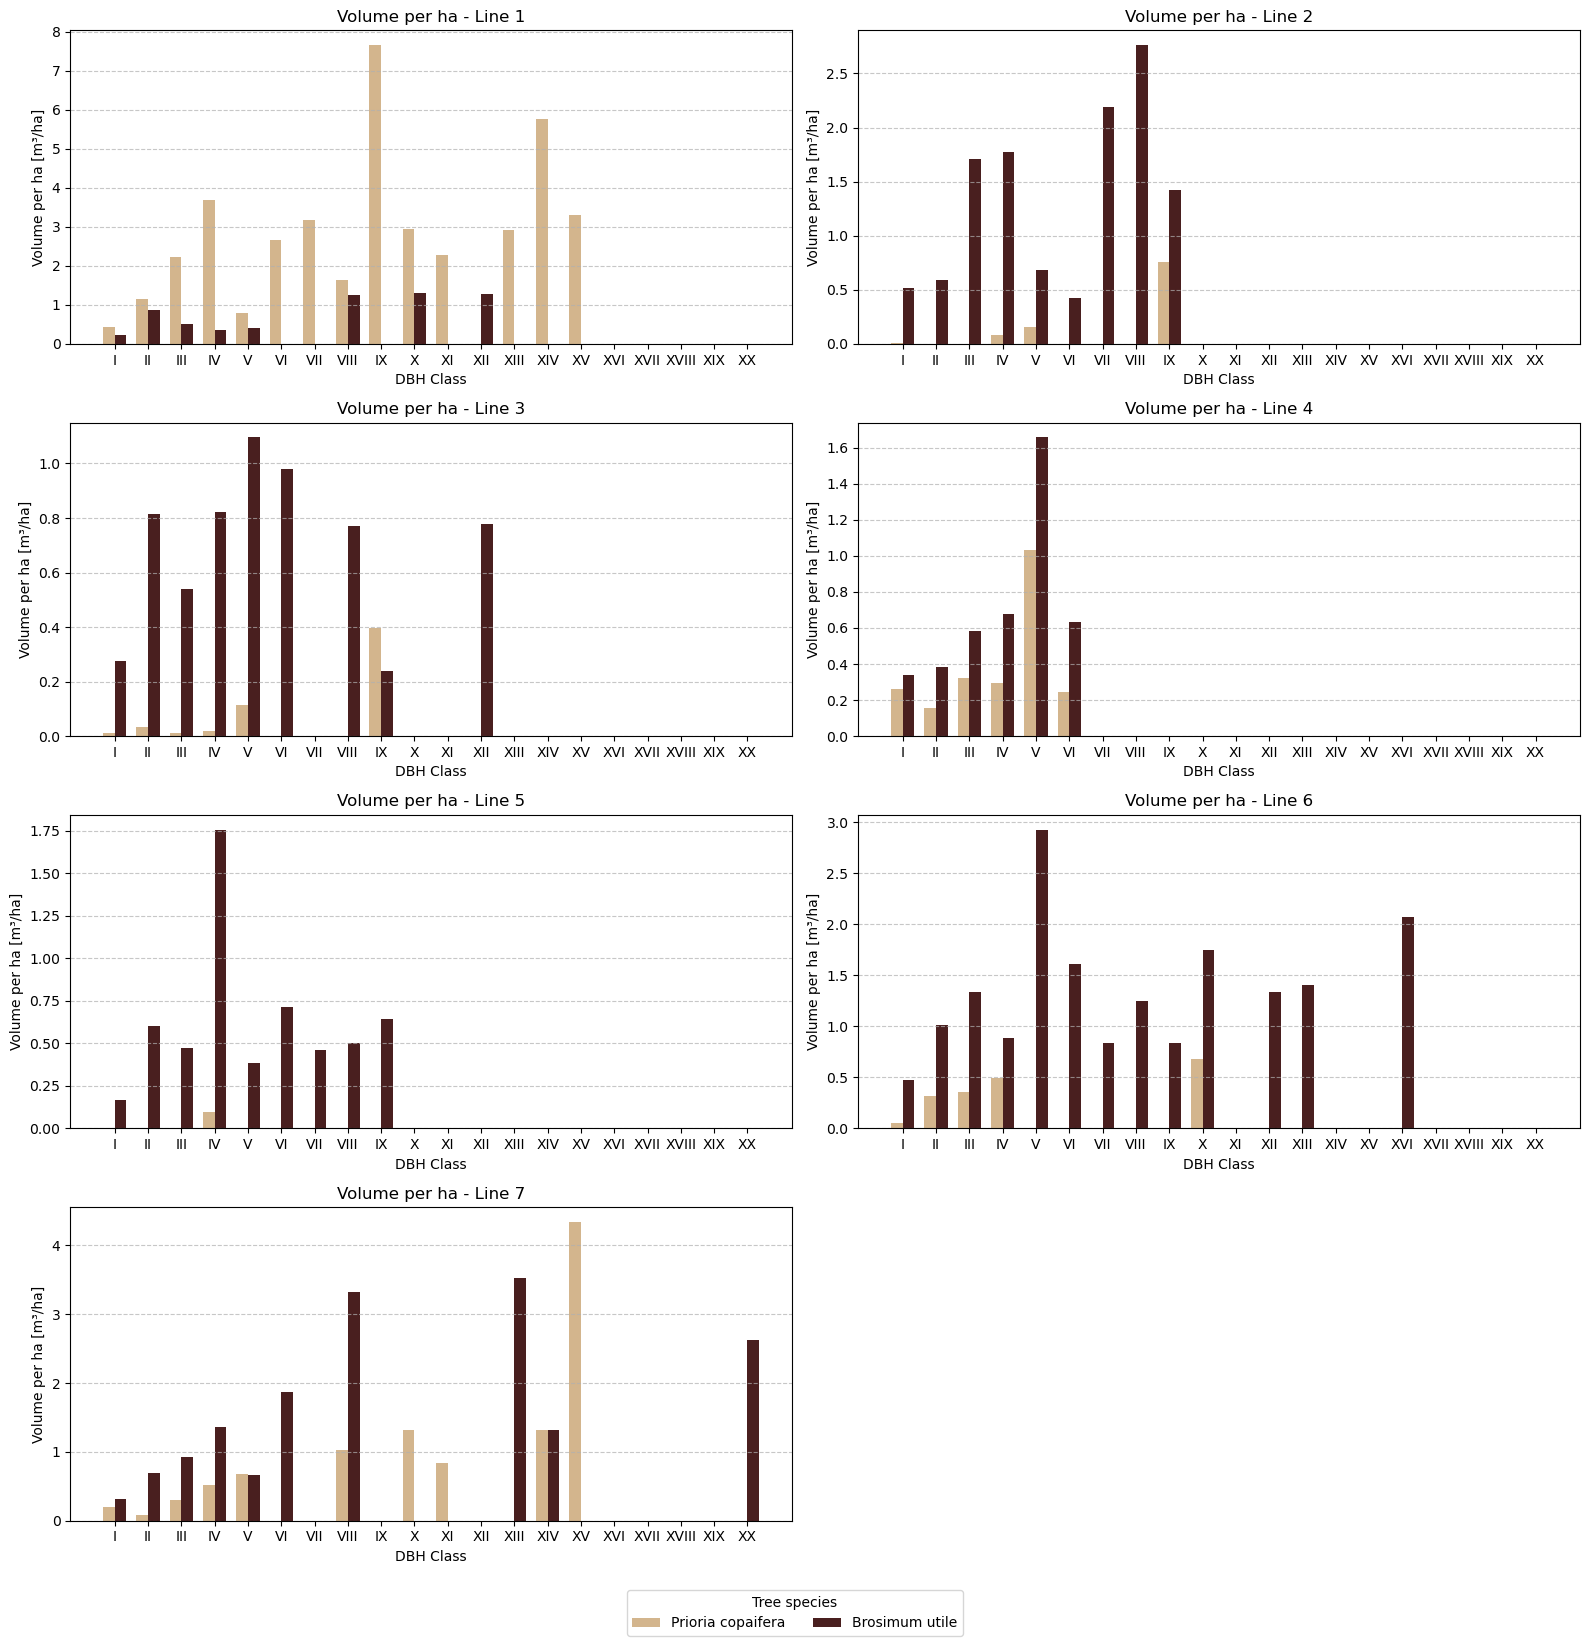

In [26]:
# Create a 4x2 matrix of subplots for Basal Area per ha by DBH Class for each line number
# Side-by-side bars per species
species_order = ['Prioria copaifera', 'Brosimum utile']
color_map = {
    'Brosimum utile': '#491f1f',
    'Prioria copaifera': '#D3B58D'
}

fig, axes = plt.subplots(4, 2, figsize=(16, 16))
axes = axes.flatten()

# Ensure plot area and counts exist; fall back to defaults if not
try:
    plot_size_ha
except NameError:
    plot_size = 5000
    plot_size_ha = plot_size / 10000

plot_counts = df.groupby('Line Number')['Plot'].nunique()
line_area_ha = plot_counts * plot_size_ha

# determine ordered DBH Class categories
if hasattr(df["DBH Class"], "cat"):
    dbh_categories = list(df["DBH Class"].cat.categories)
else:
    dbh_categories = sorted(df["DBH Class"].unique())

width = 0.35

for i, line_num in enumerate(range(1, 8)):
    line_data = species_df[species_df["Line Number"] == line_num]

    # Basal area summed by DBH Class and Scientific name
    ba = (
        line_data
        .groupby(["DBH Class", "Scientific name"])['Volume [m3]']
        .sum()
        .unstack(fill_value=0)
    )

    # ensure both species are present and in the specified order
    for s in species_order:
        if s not in ba.columns:
            ba[s] = 0
    ba = ba[species_order]

    # ensure all DBH categories are present
    ba = ba.reindex(index=dbh_categories, fill_value=0)

    # compute per-hectare basal area
    area = line_area_ha.get(line_num, np.nan)
    if area and area > 0:
        ba_per_ha = ba / area
    else:
        ba_per_ha = ba * np.nan

    x = np.arange(len(ba_per_ha))

    for j, species in enumerate(species_order):
        offsets = (j - (len(species_order) - 1)/2) * width
        axes[i].bar(x + offsets, ba_per_ha[species].values, width, label=species if i == 0 else "", color=color_map.get(species))

    axes[i].set_xlabel('DBH Class')
    axes[i].set_ylabel('Volume per ha [m³/ha]')
    axes[i].set_title(f'Volume per ha - Line {line_num}')
    axes[i].set_xticks(x)
    axes[i].grid(axis='y', linestyle='--', alpha=0.7)
    axes[i].set_xticklabels(ba_per_ha.index, rotation=0)

# Place a single horizontal legend centered below all subplots with a title
legend = fig.legend(ncol=len(species_order), loc='lower center', bbox_to_anchor=(0.5, -0.03), frameon=True, title='Tree species')
legend.get_title().set_fontsize('medium')
try:
    legend._legend_box.align = "center"
except Exception:
    pass

# Hide the last empty subplot
axes[7].set_visible(False)

# Adjust layout to make room for the legend
plt.tight_layout(rect=[0, 0.01, 1, 1])
plt.show()

In [27]:
# Sum basal area by line and only for the two target species, then convert to per-hectare using line_area_ha
species_interest = ['Brosimum utile', 'Prioria copaifera']
basal_area_sum = (
    species_df[species_df['Scientific name'].isin(species_interest)]
    .groupby(['Line Number', 'Scientific name'])['Basal area [m2]']
    .sum()
    .unstack(fill_value=0)
)

# Convert to per-hectare
basal_area_ha_by_line = basal_area_sum.div(line_area_ha, axis=0)

# Keep specified species order and lines order (if available), then round
basal_area_ha_by_line = basal_area_ha_by_line.reindex(columns=species_interest, fill_value=0)
try:
    basal_area_ha_by_line = basal_area_ha_by_line.reindex(lines)
except NameError:
    pass

basal_area_ha_by_line = basal_area_ha_by_line.round(3)

# Display the result
print('Basal area (m²/ha) by Line and Species:')
display(basal_area_ha_by_line)


Basal area (m²/ha) by Line and Species:


C:\Users\migue\AppData\Local\Temp\ipykernel_20976\3658066777.py:5: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  .groupby(['Line Number', 'Scientific name'])['Basal area [m2]']


Scientific name,Brosimum utile,Prioria copaifera
Line Number,,
1,1.101,4.822
2,2.059,0.117
3,1.445,0.145
4,1.065,0.589
5,1.049,0.031
6,3.071,0.319
7,3.127,1.729


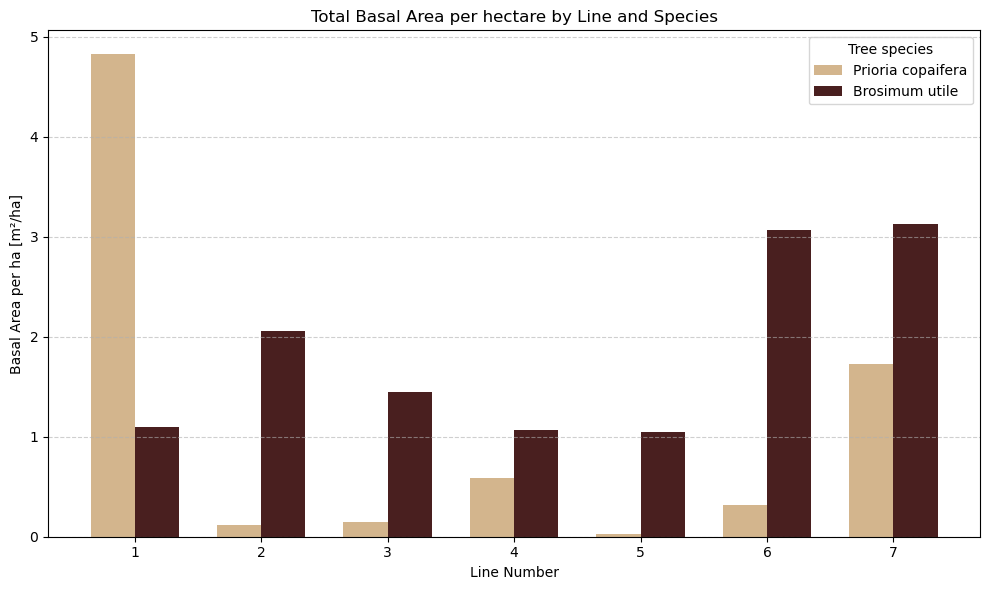

In [28]:
# Check if you accidentally did this:
import lines 

# It should be:
lines = [1, 2, 3, 4, 5, 6, 7] # Or whatever your line IDs are

species_order = ['Prioria copaifera', 'Brosimum utile']
color_map = {
    'Brosimum utile': '#491f1f',
    'Prioria copaifera': '#D3B58D'
}

fig, ax = plt.subplots(figsize=(10, 6))
width = 0.35
x = np.arange(len(basal_area_ha_by_line))
for j, species in enumerate(species_order):
    offsets = (j - (len(species_order) - 1)/2) * width
    ax.bar(x + offsets, basal_area_ha_by_line[species].values, width, label=species, color=color_map.get(species))
ax.set_xlabel('Line Number')
ax.set_ylabel('Basal Area per ha [m²/ha]')
ax.set_title('Total Basal Area per hectare by Line and Species')
ax.set_xticks(x)
ax.set_xticklabels(basal_area_ha_by_line.index.astype(str))
ax.legend(title='Tree species')
ax.grid(axis='y', linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()

In [29]:
# Check if you accidentally did this:
import lines 

# It should be:
lines = [1, 2, 3, 4,5, 6, 7] # Or whatever your line IDs are

# Sum volume by line for target species, then convert to per-hectare
species_interest = ['Brosimum utile', 'Prioria copaifera']
volume_sum = (
    species_df[species_df['Scientific name'].isin(species_interest)]
    .groupby(['Line Number', 'Scientific name'])['Volume [m3]']
    .sum()
    .unstack(fill_value=0)
)

# Convert to per-hectare
volume_ha_by_line = volume_sum.div(line_area_ha, axis=0)

# Maintain species and line order, then round
volume_ha_by_line = volume_ha_by_line.reindex(columns=species_interest, fill_value=0)
try:
    volume_ha_by_line = volume_ha_by_line.reindex(lines)
except NameError:
    pass

volume_ha_by_line = volume_ha_by_line.round(3)

# Display the result
print('Volume (m³/ha) by Line and Species:')
display(volume_ha_by_line)

Volume (m³/ha) by Line and Species:


C:\Users\migue\AppData\Local\Temp\ipykernel_20976\397381541.py:11: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  .groupby(['Line Number', 'Scientific name'])['Volume [m3]']


Scientific name,Brosimum utile,Prioria copaifera
Line Number,,
1,6.224,40.665
2,12.048,1.002
3,6.316,0.589
4,4.262,2.305
5,5.698,0.094
6,17.734,1.907
7,16.623,10.633


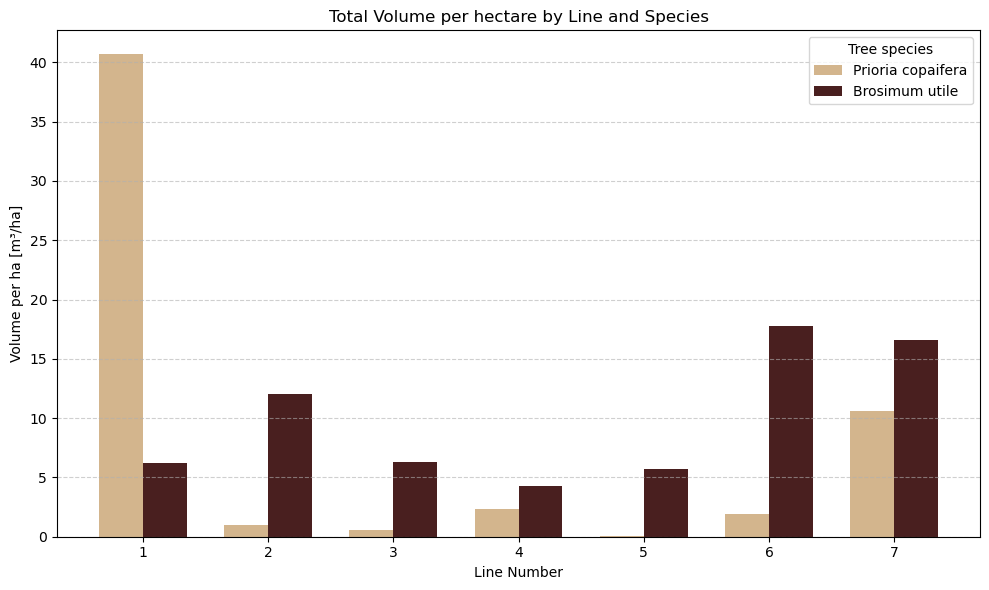

In [30]:
# Check if you accidentally did this:
import lines 

# It should be:
lines = [1, 2, 3, 4,5, 6, 7] # Or whatever your line IDs are

species_order = ['Prioria copaifera', 'Brosimum utile']
color_map = {
    'Brosimum utile': '#491f1f',
    'Prioria copaifera': '#D3B58D'
}

fig, ax = plt.subplots(figsize=(10, 6))
width = 0.35
x = np.arange(len(volume_ha_by_line))
for j, species in enumerate(species_order):
    offsets = (j - (len(species_order) - 1)/2) * width
    ax.bar(x + offsets, volume_ha_by_line[species].values, width, label=species, color=color_map.get(species))
ax.set_xlabel('Line Number')
ax.set_ylabel('Volume per ha [m³/ha]')
ax.set_title('Total Volume per hectare by Line and Species')
ax.set_xticks(x)
ax.set_xticklabels(volume_ha_by_line.index.astype(str))
ax.legend(title='Tree species')
ax.grid(axis='y', linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()

## 4. Considerations about tropical forest management
For Colombia’s forests, there is no clear system of silvicultural practices that provides a framework for the sustainable management of forests and ensures the availability of commercial timber to supply local markets, where such timber is highly valued for its quality. 

Tree felling is indiscriminate and is often carried out without taking into account the trees’ dimensions (diameter, height and number of trees felled). For this reason, it is important to establish a parameter that determines the optimal diameter, ensuring sufficient timber production whilst conserving enough young trees to support future forestry operations.

The application of minimum diameter cutting limit (MDCL) as a silvicultural practice is a common mechanism for regulating timber harvesting in mixed-age forests, with a focus on sustainable management and planning (BOLFOR, 2003). Lamprecht (1990) defines the minimum cutting diameter limit (MCDL) as a silvicultural system in which the thickest trees belonging to species attractive to the timber market are harvested, whilst retaining the medium and small diameter classes in order to ensure natural regeneration and sustainable timber production. In this context, the same author sets out the following considerations to bear in mind when determining the minimum commercial diameter (MCD) for a given species:

* There are sufficient trees of sufficient thickness to ensure profitable harvesting.
* The MCDL is defined by a large diameter.
* The species of interest exhibit a regular diameter distribution.

The selective felling of the largest trees defined by the DMC is suited to the market and trade in tropical hardwoods, which is geared towards the production of large-dimension, high-quality sawn timber (BOLFOR, 2003). Sist (2001) proposes that silvicultural practices in this case should be directed towards sustainable productivity in accordance with the following guidelines: 

* Maintaining timber harvesting and extraction rates below an acceptable limit that is compatible with timber yield capacity.
* Limiting the impacts of timber extraction on the diversity and composition of tree species.
* Maintaining populations of commercially important timber species whilst reducing the impacts of their exploitation on their ecological dynamics.

It is therefore important not only to set a minimum felling diameter within the framework of forest management, but also to establish a maximum felling limit based on the structure of the species within the forest; that is, on the size and dominance of the trees within the ecosystem and their distribution within it. Similarly, it is important to determine, beyond the volume to be harvested, the size of the clearings to be created, which should not exceed 600 m² (Sist, 2001).

Furthermore, Louman & Stanley (2002) suggest that the MDCL should be defined according to forest dynamics data and provide a technical justification for the definition of the parameter. It is important to identify the diameter classes in which trees in poor health are found, as the MDCL must be smaller than the diameter of those trees. Similarly, the DMC set is inversely proportional to sawmill residues; therefore, if trees of smaller diameter are harvested, extraction will be more complicated, more costly and less profitable.

It is important to take into account the ecological characteristics of the species under study when determining the MDCL, in relation to the growth of the species in question and its reproductive capacity within the forest. Accordingly, Louman & Stanley (2002) set out the following considerations for determining the MDCL, with the aim of achieving a balance between harvesting and conservation:

* The MDCL must ensure a balance between the harvested basal area and the forest’s resilience to recover the loss of tree individuals during the stipulated felling cycle.
* The MDCL must be greater than the size range in which trees have their highest seed production.

An optimal MDCL in terms of profitability and productivity is established at the point at which a tree ceases to grow and reaches maturity; this occurs at a stage where the diameter at breast height (DBH) lies between the maximum average annual growth rate and the point at which the tree stops growing (Louman & Stanley, 2002). Similarly, MDCLs should be set at a stage of development where the mortality rate of the species is lowest and average annual increments have already been maximised. The diameter that maximises the average annual increment indicates the maximum size a species can reach, given that, beyond that size, growth and mortality are reduced and, consequently, the productivity of the trees is diminished (Alder, 1992). 

Designating a MDCL for any species can be formulated based on various factors, taking into account the value of the timber in the different diameter classes, the end products to be obtained from it, growth rates, the diameter distribution of the species in question, as well as the requirements for marking seed trees (Fredericksen *et al.*, 2001; cited by BOLFOR, 2003).

There is no clear criterion for determining the MDCLs for forest species in tropical forests. However, the rigour with which forest inventories are carried out for high-canopy, low-canopy and open-canopy forests using permanent sample plots will help to clarify the ecological dynamics of the species intended for harvesting, thereby providing data on their growth over specific periods and thus determine the productivity of these species to identify the optimal sizes for timber harvesting, thereby ensuring the survival and recovery of harvested volumes, allowing the remaining trees to grow, and securing timber productivity for future harvests through the application of silvicultural treatments that promote this productive dynamic.

To encourage improvements in the productivity of stands of these species, Dykstra (2001) states that it is not sufficient to apply minimum and maximum felling diameters within the framework of the Reduced Impact Logging (RIL) practices proposed by the FAO and ITTO, which are aimed at reducing the environmental and social effects and impacts resulting from industrial logging by applying appropriate technologies for the extraction of raw materials.
It is important to apply silvicultural treatments that focus not only on reduced-impact logging for the care of remaining trees and the sustainable extraction of timber, but also on the protection and conservation of ecosystems and their components. Many of the conservation efforts undertaken in the context of RIL have focused on minimising changes in canopy cover, establishing minimum felling diameters, minimising damage to remaining trees, and restricting the extraction processes applied during post-harvest stages (Fredericksen & Putz, 2003).

According to the previous considerations, which decisions would you make and considerate for a sustainable forest management for these tree species?

## References

Alder, D. (1992). Simple methods for calculating minimum diameter and sustainable yield in mixed tropical forest. En F. R. Miller, & K. L. Adam (Eds.), *Wise management of tropical forests.* Proceedings of the Oxford Conference on Tropical Forests. (pp. 189-200). Oxford: Oxford Forestry Institute, University of Oxford.

BOLFOR (2003). *Diámetros Mínimos de Corta en Bosques Tropicales de Bolivia: Recomendaciones basadas en Investigación Forestal.* Proyecto BOLFOR – The Management Trust, Santa Cruz de la Sierra – Bolivia. 11 p.

Dykstra, D. (2001). Ideas antiguas y nuevas sobre la extracción de impacto reducido. *Actualidad Forestal, 9*(2), 3-4.

Fredericksen, T., Contreras, F., & Pariona, W. (2001). *Guía de silvicultura para bosques tropicales de Bolivia.* Santa Cruz, Bolivia: Proyecto BOLFOR. 81 p.

Fredericksen, T. S., & Putz, F. E. (2003). Silvicultural intensification for tropical forest conservation. *Biodiversity and Conservation, 12*(7), 1445-1453. [doi:10.1023/a:1023673625940](https://link.springer.com/article/10.1023/A:1023673625940)

Lamprecht, H. (1990). *Silvicultura en los trópicos: Los ecosistemas forestales y sus especies arbóreas; posibilidades y métodos para un aprovechamiento sostenido*. Deutsche Gesellschaft für Zusammenarbeit (GTZ) GmbH. Rosdorf: TZ-Verl.-Ges. ISBN: 3-88085-440-8.

Louman, B. & Stanley S. (2002). Análisis e interpretación de resultados de inventarios forestales. En L. Orozco, & C. Brumér (Eds.), *Inventarios forestales para bosques latifoliados en América Central.* (pp. 216-248). Turrialba: CATIE. ISBN: 9977-57-384-0.

Sist, P. (2001). La EIR no va a funcionar solamente con un diámetro mínimo de corta. *Actualidad Forestal, 9*(2), 5.